# possibilty a better version of feedback simulator

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['AA','UA']
hrf_delay = 3 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [58]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1'])

for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-zscoresample_ss.npy")
            tc = np.load(tc_file)

            # estimate percent signal change for each roi (mean = 100, variation relative to mean, as in TBV)
            # tc_0 = tc[:,0] / abs(np.mean(tc[:,0])) * 100
            # tc_1 = tc[:,1] / abs(np.mean(tc[:,1])) * 100
            # tc_2 = tc[:,2] / abs(np.mean(tc[:,2])) * 100
            # tc_3 = tc[:,3] / abs(np.mean(tc[:,3])) * 100

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

In [61]:
# tests
tc_file = os.path.join(tc_dir,'sub-01_0.5_AA_hp_ss.npy')
tc = np.load(tc_file)

# estimate percent signal change for each roi (mean = 100, variation relative to mean, as in TBV)
tc_0 = tc[:,0] / np.mean(tc[:,0]) * 100
tc_1 = tc[:,1] / np.mean(tc[:,1]) * 100

# mean of tc_0 and tc_1
tc_mean = np.mean([tc_0,tc_1],axis=0)

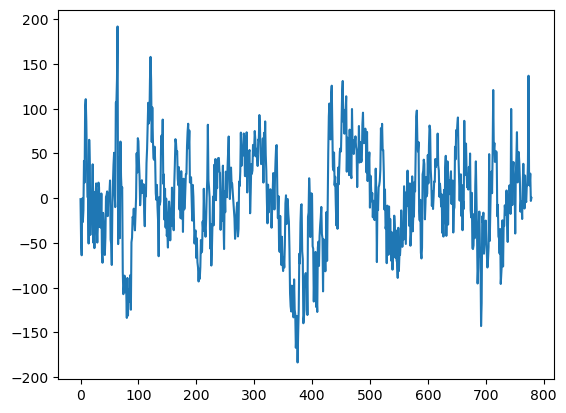

In [65]:
plt.plot(tc[:,0])

In [59]:
df

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1
0,sub-01,0.50,AA,"[-765.05273, -35517.5, -46201.01, -174.70349, ...","[-8050.929, -21288.125, -38287.668, 29356.854,...","[160.47894, 67.40638, -250.4317, -364.018, -60...","[167.72263, 276.3649, -430.46332, -269.98102, ...","[-4407.991, -28402.812, -42244.34, 14591.075, ...","[164.10078, 171.88564, -340.4475, -316.9995, -..."
1,sub-01,0.50,UA,"[-587.0245, -1809.378, -1240.5367, 1466.3928, ...","[-339.47455, -699.4259, -971.3685, 2.4123874, ...","[128.58716, 164.98961, 42.419434, -213.55174, ...","[91.34547, 123.57724, 11.305971, -147.61244, -...","[-463.2495, -1254.402, -1105.9526, 734.4026, -...","[109.96631, 144.28342, 26.862701, -180.58209, ..."
2,sub-01,0.75,AA,"[2191.6174, 1719.5858, -4643.3623, -4119.7773,...","[356.43515, 1174.6324, 515.7108, -617.2081, -8...","[199.22331, -50.817047, -365.779, -463.0423, -...","[147.57251, -132.74522, -683.84686, -339.41617...","[1274.0262, 1447.1091, -2063.8257, -2368.4927,...","[173.39792, -91.781136, -524.8129, -401.22925,..."
3,sub-01,0.75,UA,"[-605.14276, -639.6802, 84.449425, -388.2616, ...","[-488.0994, -429.65747, 625.6942, -68.13082, 9...","[126.379486, 246.33917, -546.95166, -360.6446,...","[74.86716, 203.39403, -358.11652, -218.96573, ...","[-546.6211, -534.6688, 355.0718, -228.19621, 8...","[100.62332, 224.86661, -452.5341, -289.80518, ..."
4,sub-01,1.00,AA,"[1086.6117, -4318.7485, -3104.9468, -3400.788,...","[253.78224, -783.2152, -620.34375, -856.09906,...","[181.28137, -597.52405, -486.83286, -174.91115...","[157.4928, -384.86798, -348.92114, -91.303215,...","[670.19696, -2550.982, -1862.6453, -2128.4436,...","[169.38708, -491.196, -417.877, -133.10718, -1..."
...,...,...,...,...,...,...,...,...,...
115,sub-23,0.75,UA,"[-14748.95, -32414.984, -31885.64, -46000.52, ...","[-440.51422, -631.37354, -988.8319, -339.04944...","[71.810844, -279.9766, -736.9167, -910.7142, -...","[76.1522, -454.5744, -804.2085, -1095.9039, -1...","[-7594.7324, -16523.18, -16437.236, -23169.785...","[73.98152, -367.2755, -770.5626, -1003.3091, -..."
116,sub-23,1.00,AA,"[-1933.6185, 13.179532, -1324.5728, -2336.3901...","[-337.11053, 621.5617, -755.9492, -1186.9531, ...","[-452.61374, -2162.0488, -4250.2607, -1290.446...","[158.62212, -946.34717, -1462.5194, -635.2045,...","[-1135.3645, 317.3706, -1040.261, -1761.6716, ...","[-146.99582, -1554.198, -2856.3901, -962.8253,..."
117,sub-23,1.00,UA,"[-1939.5344, -1557.0442, -3232.4192, -6687.357...","[-711.6744, -1190.847, -996.71783, -790.4361, ...","[-2945.2405, -7496.7886, -350.65356, -6.391635...","[-335.5454, -821.1672, -722.058, 181.76428, 19...","[-1325.6044, -1373.9456, -2114.5686, -3738.896...","[-1640.393, -4158.978, -536.3558, 87.686325, -..."
118,sub-23,2.50,AA,"[128.18047, -1906.9574, -465.63596, -1359.6868...","[71.728874, -2552.437, -2069.874, -1109.9559, ...","[142.29767, -374.0899, 285.19904, 458.1756, 53...","[220.95895, -564.49054, 30.436846, 340.21426, ...","[99.954666, -2229.6973, -1267.755, -1234.8213,...","[181.62831, -469.29022, 157.81795, 399.19495, ..."


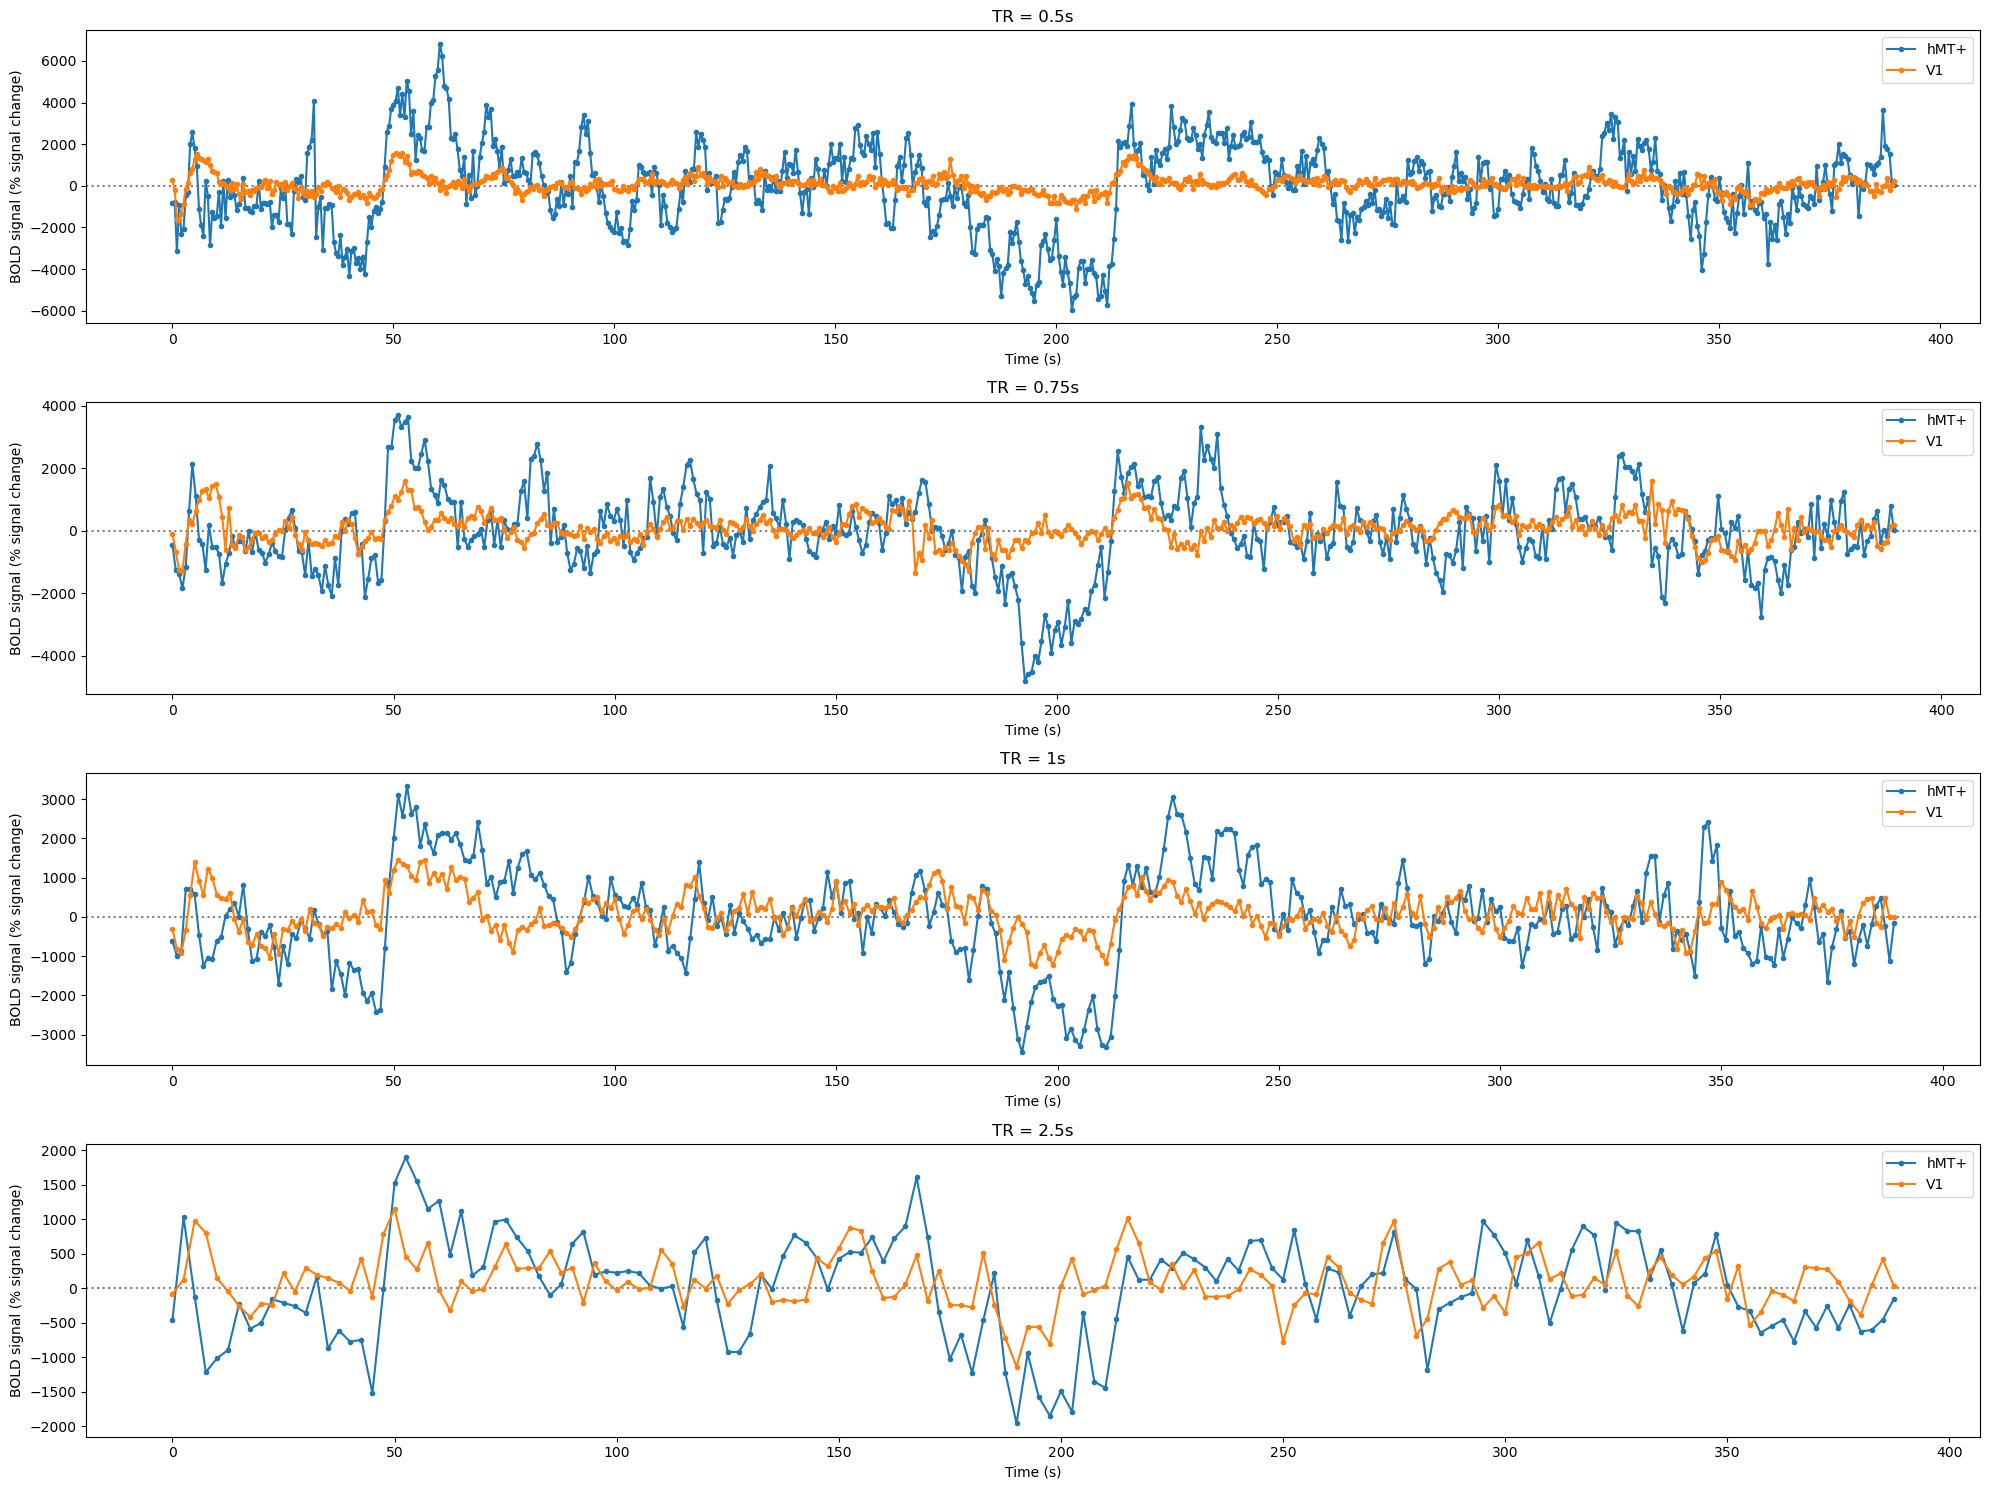

In [60]:
# Plot timecourses per TR
f, axs = plt.subplots(len(tr_list), 1, figsize=(20, 15))

for tr_idx, tr in enumerate(tr_list):

    n_volumes = n_volumes_list[tr_idx]

    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()
    m2 = df[df['tr']==tr]['bilateral_v1'].mean()
    s2 = df[df['tr']==tr]['bilateral_v1'].values.std()

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes*tr, tr)

    # add horizontal line at y=0
    axs[tr_idx].axhline(y=0, color='k', linestyle=':', alpha=0.5)

    # plot m1 and m2 in different colors with legend
    axs[tr_idx].plot(time_vector, m1, label='hMT+', marker='.')
    axs[tr_idx].plot(time_vector, m2, label='V1', marker='.')
    axs[tr_idx].legend()

    # plot the standard deviation as a shaded area
    #axs[tr_idx].fill_between(time_vector, m1-s1, m1+s1, alpha=0.2)
    #axs[tr_idx].fill_between(time_vector, m2-s2, m2+s2, alpha=0.2)

    # add title and axis labels
    axs[tr_idx].set_title('TR = ' + str(tr) + 's')
    axs[tr_idx].set_xlabel('Time (s)')
    axs[tr_idx].set_ylabel('BOLD signal (% signal change)')

plt.tight_layout()
plt.show()

In [ ]:
# Plot timecourses per ROI (bilateral_mt and bilateral_v1)
f, axs = plt.subplots(2, 1, figsize=(20, 15))

time_vectors = {}
# create time vectors for each TR
for tr_idx,tr in enumerate(tr_list):
    n_volumes = n_volumes_list[tr_idx]
    time_vectors[tr_idx] = np.arange(0, n_volumes*tr, tr)

# plot hMT+ timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()

    axs[0].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s')
    axs[0].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[0].set_title('hMT+ timecourses')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('BOLD signal (PSC)')
axs[0].legend()

# plot V1 timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_v1'].mean()
    s1 = df[df['tr']==tr]['bilateral_v1'].values.std()

    axs[1].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s')
    axs[1].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[1].set_title('V1 timecourses')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('BOLD signal (PSC)')
axs[1].legend()

plt.show()